# Orders Visualizations

Business-focused visualizations for the Orders PBIP report.

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
sns.set_theme(style='whitegrid')
orders = pd.read_csv(Path('Orders.csv'))
orders['Order Date'] = pd.to_datetime(orders['Order Date'], dayfirst=True, errors='coerce')
orders['Ship Date'] = pd.to_datetime(orders['Ship Date'], dayfirst=True, errors='coerce')
orders['Shipping Days'] = (orders['Ship Date'] - orders['Order Date']).dt.days
orders['Profit Margin'] = orders['Profit'] / orders['Sales'].replace(0, np.nan)
print(f'Loaded {len(orders):,} rows and {orders.shape[1]} columns')
display(orders.head())

Loaded 10,194 rows and 25 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,TotalPrice,TotalCost,Shipping Days,Profit Margin
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,10.696800,8.557440,4,0.3375
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,4.113500,3.290800,4,-1.5500
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Labels,Avery 508,11.784,3,0.2,4.2717,2.437433,1.949947,4,0.3625
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,112.436933,89.949547,4,-0.2375
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,4.817333,3.853867,7,0.2500


## KPI overview

In [12]:
kpis = pd.Series({'Sales': orders['Sales'].sum(), 'Profit': orders['Profit'].sum(), 'Profit Margin %': orders['Profit'].sum() / orders['Sales'].sum() * 100, 'Orders': orders['Order ID'].nunique(), 'Customers': orders['Customer ID'].nunique(), 'Average Shipping Days': orders['Shipping Days'].mean()})
display(kpis.to_frame('Value'))

,Value
Sales,2.326534e+06
Profit,2.922968e+05
Profit Margin %,1.256361e+01
Orders,5.111000e+03
Customers,8.040000e+02
Average Shipping Days,3.961350e+00


## Sales and profit trends

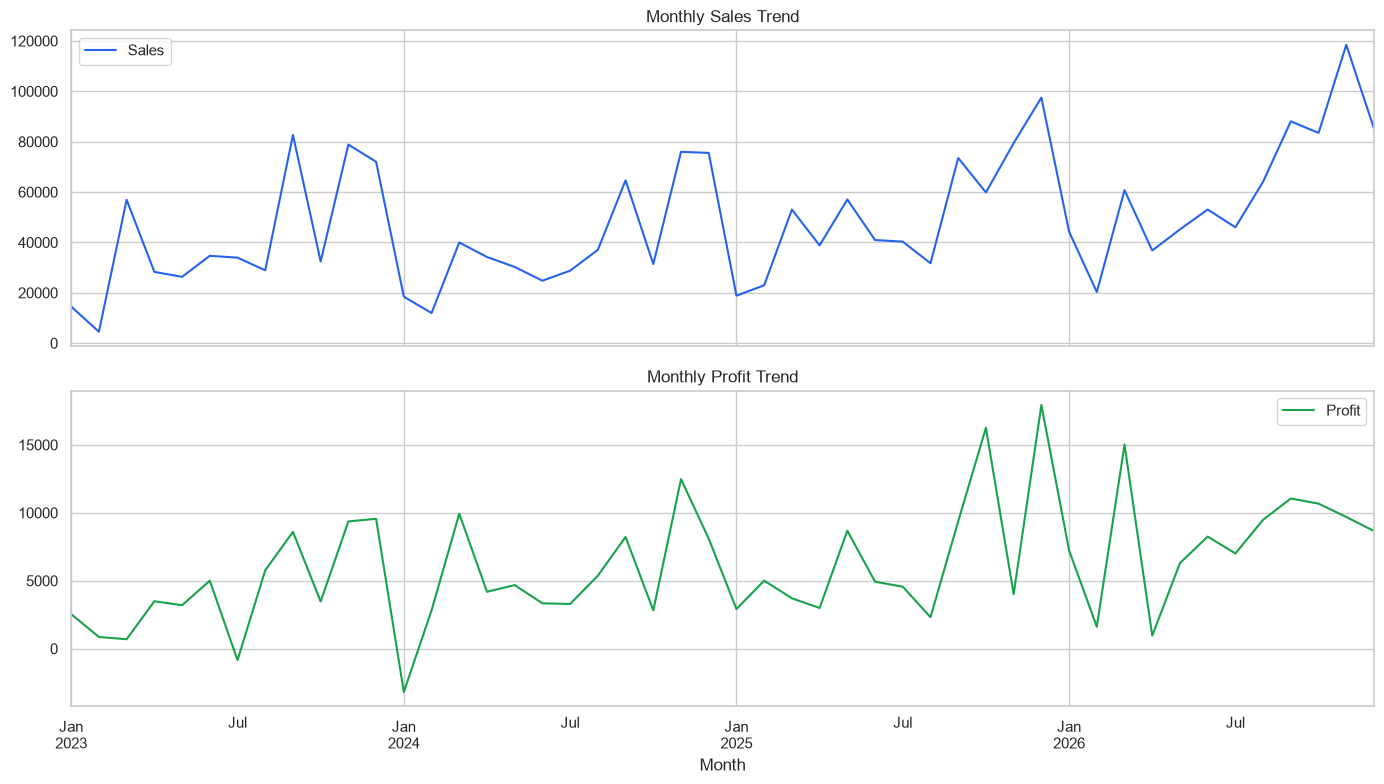

,Month,Sales,Profit
36,2026-01-01,44259.2140,7231.6391
37,2026-02-01,20301.1334,1613.8720
38,2026-03-01,60728.4808,15013.0910
39,2026-04-01,36779.0361,957.5300
40,2026-05-01,45155.4822,6299.8072
41,2026-06-01,53056.0777,8246.5707
42,2026-07-01,45989.4960,7006.5012
43,2026-08-01,64129.7580,9488.0722
44,2026-09-01,88064.5320,11050.8024
45,2026-10-01,83474.7832,10670.5312


In [13]:
monthly = orders.dropna(subset=['Order Date']).assign(Month=lambda d: d['Order Date'].dt.to_period('M').dt.to_timestamp()).groupby('Month').agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum')).reset_index()
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
monthly.plot(x='Month', y='Sales', ax=axes[0], color='#2563eb', title='Monthly Sales Trend')
monthly.plot(x='Month', y='Profit', ax=axes[1], color='#16a34a', title='Monthly Profit Trend')
plt.tight_layout(); plt.show()
display(monthly.tail(12))

## Category, regional, and discount performance

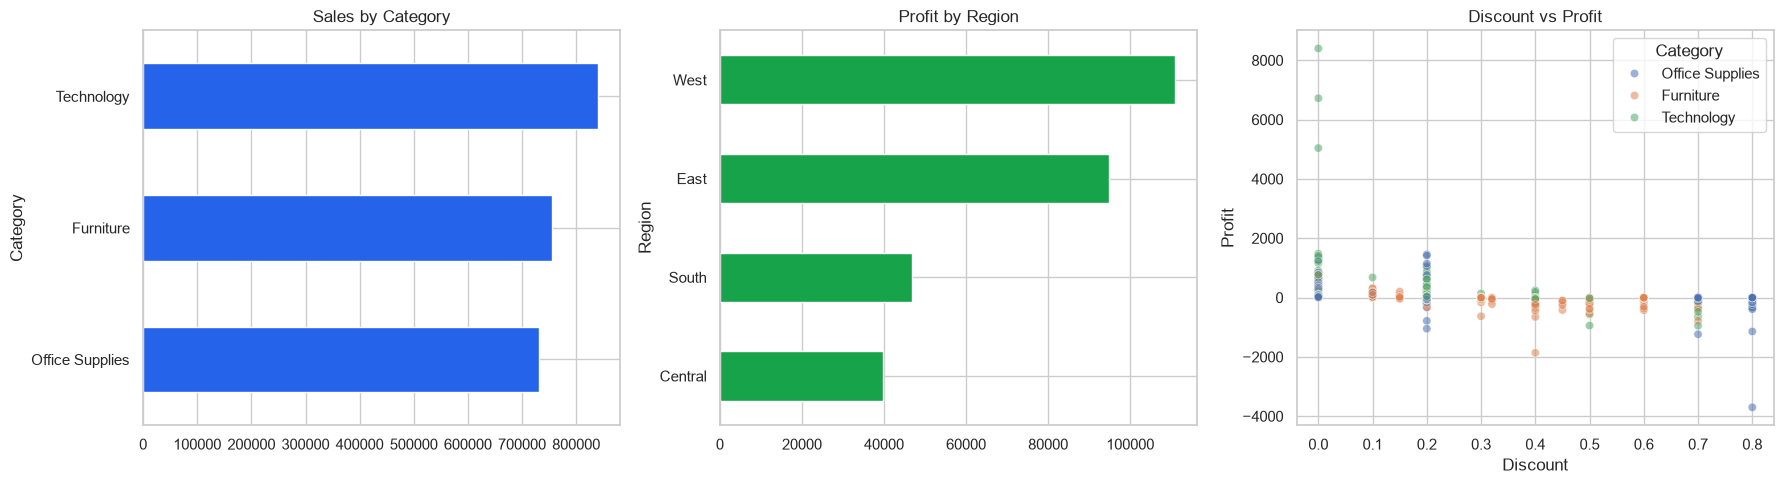

,Category,Region,Sales,Profit,Margin
0,Furniture,Central,164537.6518,-2802.2067,-0.185232
1,Furniture,East,212231.6960,3444.7448,0.095027
2,Furniture,South,117298.6840,6771.2061,0.141662
4,Office Supplies,Central,168216.7090,8970.0817,-0.159646
3,Furniture,West,260679.7295,12316.2514,0.102087
6,Office Supplies,South,125651.3130,19986.3928,0.163165
10,Technology,South,148771.9080,19991.8314,0.189488
8,Technology,Central,170416.3120,33697.4320,0.175124
5,Office Supplies,East,211658.4010,42996.7397,0.210226
11,Technology,West,252766.9880,44412.3364,0.155173


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
orders.groupby('Category')['Sales'].sum().sort_values().plot.barh(ax=axes[0], color='#2563eb', title='Sales by Category')
orders.groupby('Region')['Profit'].sum().sort_values().plot.barh(ax=axes[1], color='#16a34a', title='Profit by Region')
sns.scatterplot(data=orders.sample(min(3000, len(orders)), random_state=42), x='Discount', y='Profit', hue='Category', alpha=.55, ax=axes[2])
axes[2].set_title('Discount vs Profit')
plt.tight_layout(); plt.show()
display(orders.groupby(['Category', 'Region']).agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'), Margin=('Profit Margin', 'mean')).reset_index().sort_values('Profit'))

## Shipping diagnostics

,Ship Mode,Orders,AverageShippingDays,LateOrders
0,First Class,795,2.182171,0
1,Same Day,266,0.043876,0
2,Second Class,982,3.237999,0
3,Standard Class,3068,4.995425,2


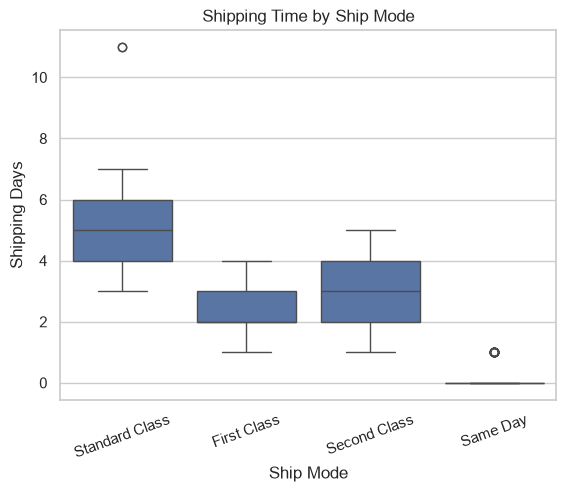

In [15]:
shipping = orders.groupby('Ship Mode').agg(Orders=('Order ID', 'nunique'), AverageShippingDays=('Shipping Days', 'mean'), LateOrders=('Shipping Days', lambda x: (x > 7).sum())).reset_index()
display(shipping)
sns.boxplot(data=orders, x='Ship Mode', y='Shipping Days')
plt.title('Shipping Time by Ship Mode'); plt.xticks(rotation=20); plt.show()

## Power BI visual mapping

- KPI cards: Sales, Profit, Margin, Orders, Customers, and average shipping days.
- Line chart: Order Date by Sales and Profit.
- Clustered columns: Category by Sales and Profit.
- Bar chart: Region by Profit.
- Scatter chart: Discount versus Profit, colored by Category.
- Shipping diagnostic: Ship Mode by average shipping days and late-order count.